🔄 Loading fully trained VGG16 model...
✅ VGG16 model is online and ready!


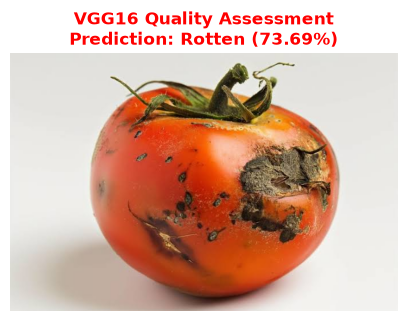

🎯 Result: State is 'Rotten' with 73.69% confidence.


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ==========================================
# 🔄 QUICK TEST CONFIGURATION
# ==========================================
# Change this path string to test different images on your Mac
TEST_IMAGE_PATH = "/Users/mevinimunaweera/Downloads/images (2).jpeg"

# Hardcoded to use your best-performing VGG16 model weights file
MODEL_PATH = "/Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models/VGG16_best_model.keras"

# Reverse class mapping dictionary matching your dataset configuration
class_mapping = {
    0: "Fresh",
    1: "Slightly_Aged",
    2: "Stale",
    3: "Spoiled",
    4: "Rotten",
}

# ==========================================
# 1. LOAD THE MODEL
# ==========================================
if not os.path.exists(MODEL_PATH):
    # Fallback to standard check if early stopping check wasn't flagged
    MODEL_PATH = "/Users/mevinimunaweera/Downloads/model_outputs/kmeans_saved_models/VGG16_model.keras"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"❌ Could not find VGG16 model weights file at: {MODEL_PATH}"
    )

print("🔄 Loading fully trained VGG16 model...")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ VGG16 model is online and ready!")

# ==========================================
# 2. RUN INFERENCE ON NEW IMAGE
# ==========================================
if not os.path.exists(TEST_IMAGE_PATH):
    print(f"⚠️ Test image file path '{TEST_IMAGE_PATH}' does not exist.")
else:
    # Read and process the image matrix matching VGG shape requirements (128x128)
    img_bgr = cv2.imread(TEST_IMAGE_PATH)

    if img_bgr is None:
        print(f"❌ Error: Could not read image at {TEST_IMAGE_PATH}")
    else:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (128, 128))
        img_normalized = img_resized / 255.0
        input_tensor = np.expand_dims(img_normalized, axis=0)

        # Execute prediction and safely flatten multi-dimensional array bounds
        predictions = model.predict(input_tensor, verbose=0)
        predictions = np.array(predictions).flatten()

        predicted_class_idx = int(np.argmax(predictions))
        confidence_score = float(predictions[predicted_class_idx]) * 100
        predicted_label = class_mapping.get(predicted_class_idx, "Unknown")

        # Set semantic title colors dynamically
        title_color = "green" if predicted_label == "Fresh" else "red"

        # Display results graph window
        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.title(
            f"VGG16 Quality Assessment\nPrediction: {predicted_label} ({confidence_score:.2f}%)",
            fontsize=12,
            color=title_color,
            weight="bold",
        )
        plt.axis("off")
        plt.show()

        print(
            f"🎯 Result: State is '{predicted_label}' with {confidence_score:.2f}% confidence."
        )
